In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind

In [2]:

repo_root = Path('/playpen-ssd/wokwen/projects/autoeval_chatbot')

# Load data_no_prompt
data_no_prompt_criteria = pd.read_csv(repo_root / 'ratings' / 'llama' / 'baseline' / 'data_no_prompt' / 'criteria_ratings.csv')
data_no_prompt_overall = pd.read_csv(repo_root / 'ratings' / 'llama' / 'baseline' / 'data_no_prompt' / 'overall_ratings.csv')

# Load prompt_no_data
prompt_no_data_criteria = pd.read_csv(repo_root / 'ratings' / 'llama' / 'baseline' / 'prompt_no_data' / 'criteria_ratings.csv')
prompt_no_data_overall = pd.read_csv(repo_root / 'ratings' / 'llama' / 'baseline' / 'prompt_no_data' / 'overall_ratings.csv')

print('Data no prompt criteria shape:', data_no_prompt_criteria.shape)
print('Data no prompt overall shape:', data_no_prompt_overall.shape)
print('Prompt no data criteria shape:', prompt_no_data_criteria.shape)
print('Prompt no data overall shape:', prompt_no_data_overall.shape)

Data no prompt criteria shape: (340, 7)
Data no prompt overall shape: (340, 4)
Prompt no data criteria shape: (270, 7)
Prompt no data overall shape: (270, 4)


In [3]:
# Merge criteria and overall for each baseline type
data_no_prompt = data_no_prompt_criteria.merge(data_no_prompt_overall, on='Conversation_Id')
prompt_no_data = prompt_no_data_criteria.merge(prompt_no_data_overall, on='Conversation_Id')

# Add baseline type column
data_no_prompt['baseline_type'] = 'data_no_prompt'
prompt_no_data['baseline_type'] = 'prompt_no_data'

# Combine into one dataframe
df = pd.concat([data_no_prompt, prompt_no_data], ignore_index=True)
print('Combined df shape:', df.shape)
print('Columns:', df.columns.tolist())

Combined df shape: (610, 11)
Columns: ['Conversation_Id', 'Clinical Accuracy & Safety_Rating', 'Clarity & Understandability_Rating', 'Actionability_Rating', 'Empathy & Supportiveness_Rating', 'Adaptability & Personalization_Rating', 'Trustworthiness & Ethical Communication_Rating', 'User_Rating', 'Observer_Rating', 'Self_Rating', 'baseline_type']


In [4]:
# Summary statistics for each baseline type
summary = df.groupby('baseline_type').agg({
    col: ['mean', 'std', 'count'] for col in df.columns if col not in ['Conversation_Id', 'baseline_type']
})
display(summary)

Clinical Accuracy & Safety_Rating                  \
                                            mean       std count   
baseline_type                                                      
data_no_prompt                           7.85000  0.654798   340   
prompt_no_data                           7.27037  1.283674   270   

               Clarity & Understandability_Rating                  \
                                             mean       std count   
baseline_type                                                       
data_no_prompt                           7.947059  0.395577   340   
prompt_no_data                           7.333333  1.249535   270   

               Actionability_Rating                  \
                               mean       std count   
baseline_type                                         
data_no_prompt             7.994118  0.108465   340   
prompt_no_data             7.759259  0.821079   270   

               Empathy & Supportiveness_Rating  ...  \
                                          mean  ...   
baseline_type                                   ...   
data_no_prompt                        7.994118  ...   
prompt_no_data                        7.803704  ...   

               Trustworthiness & Ethical Communication_Rating User_Rating  \
                                                        count        mean   
baseline_type                                                               
data_no_prompt                                            340    9.044118   
prompt_no_data                                            270    8.722222   

                               Observer_Rating                 Self_Rating  \
                     std count            mean       std count        mean   
baseline_type                                                                
data_no_prompt  1.485762   340        7.520588  1.135192   340    5.414706   
prompt_no_data  1.532991   270        7.574074  1.385021   270    7.203704   

                                
                     std count  
baseline_type                   
data_no_prompt  1.013953   340  
prompt_no_data  1.329947   270  

[2 rows x 27 columns]

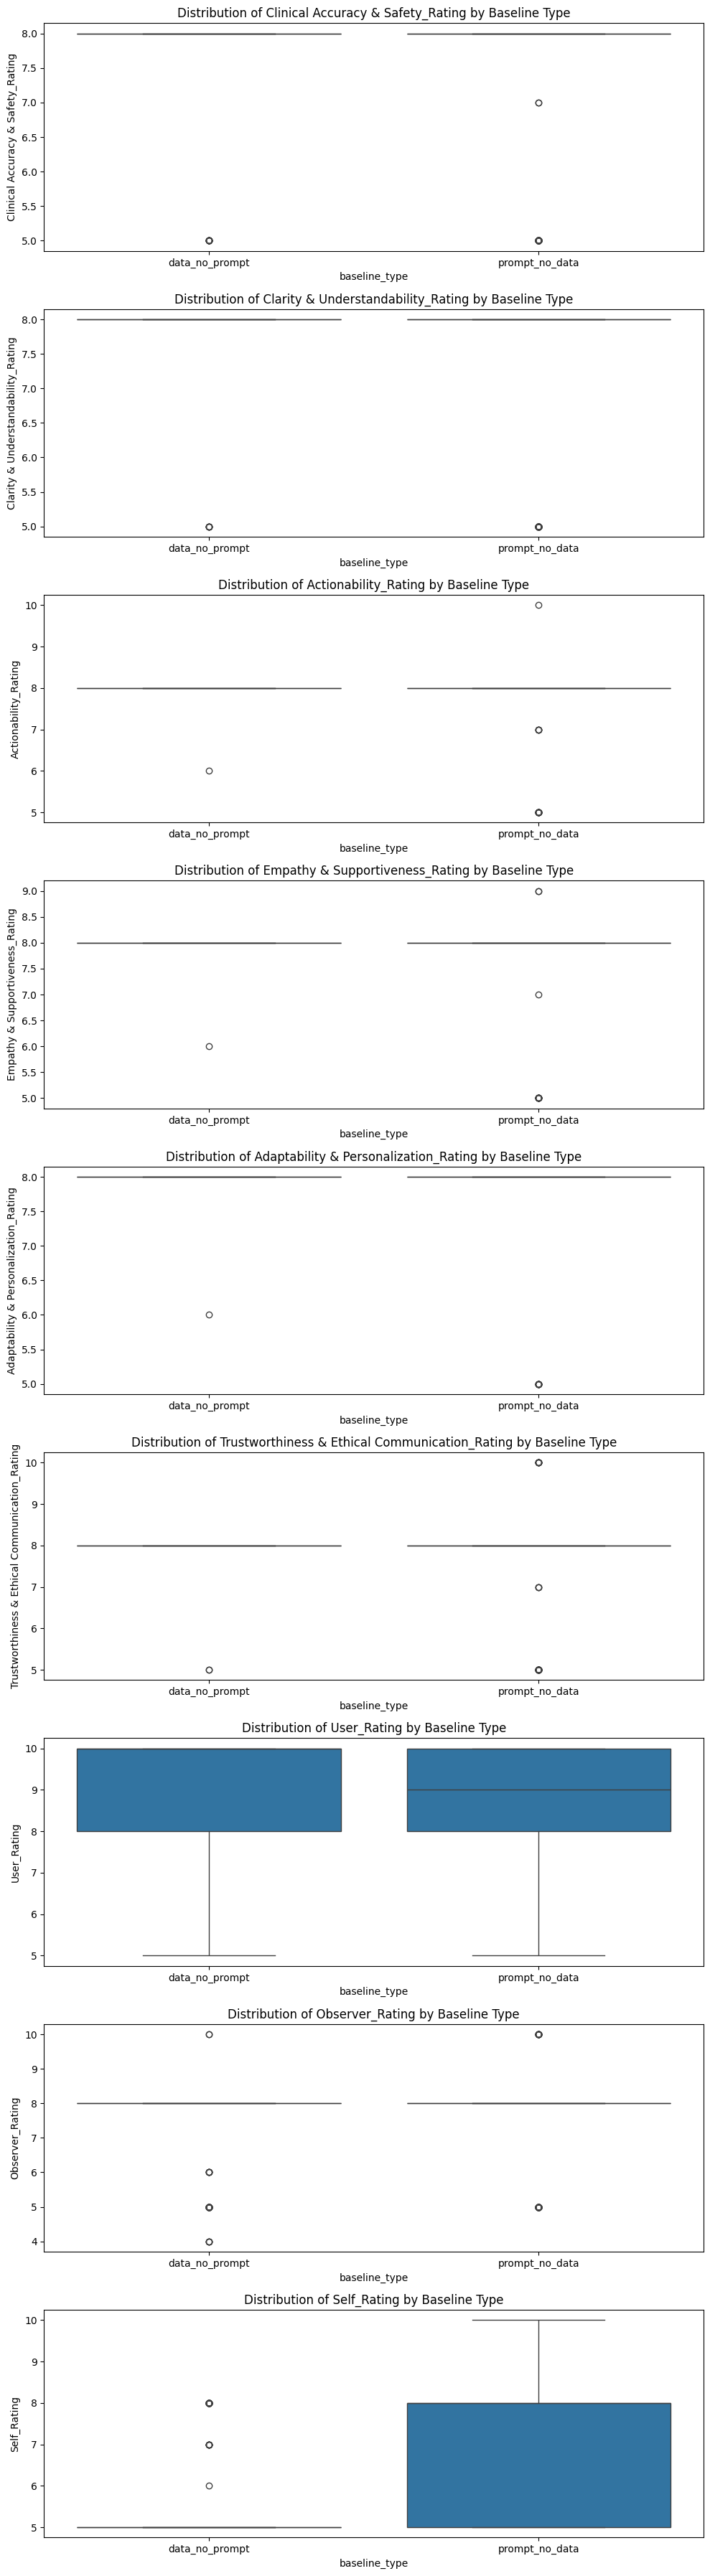

In [5]:
# Visualize distributions of criteria ratings by baseline type
criteria_cols = [c for c in df.columns if '_Rating' in c and 'baseline_type' not in c and 'Conversation_Id' not in c]
fig, axes = plt.subplots(len(criteria_cols), 1, figsize=(10, 4*len(criteria_cols)))
if len(criteria_cols) == 1:
    axes = [axes]
for i, col in enumerate(criteria_cols):
    sns.boxplot(data=df, x='baseline_type', y=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Baseline Type')
plt.tight_layout()
plt.show()

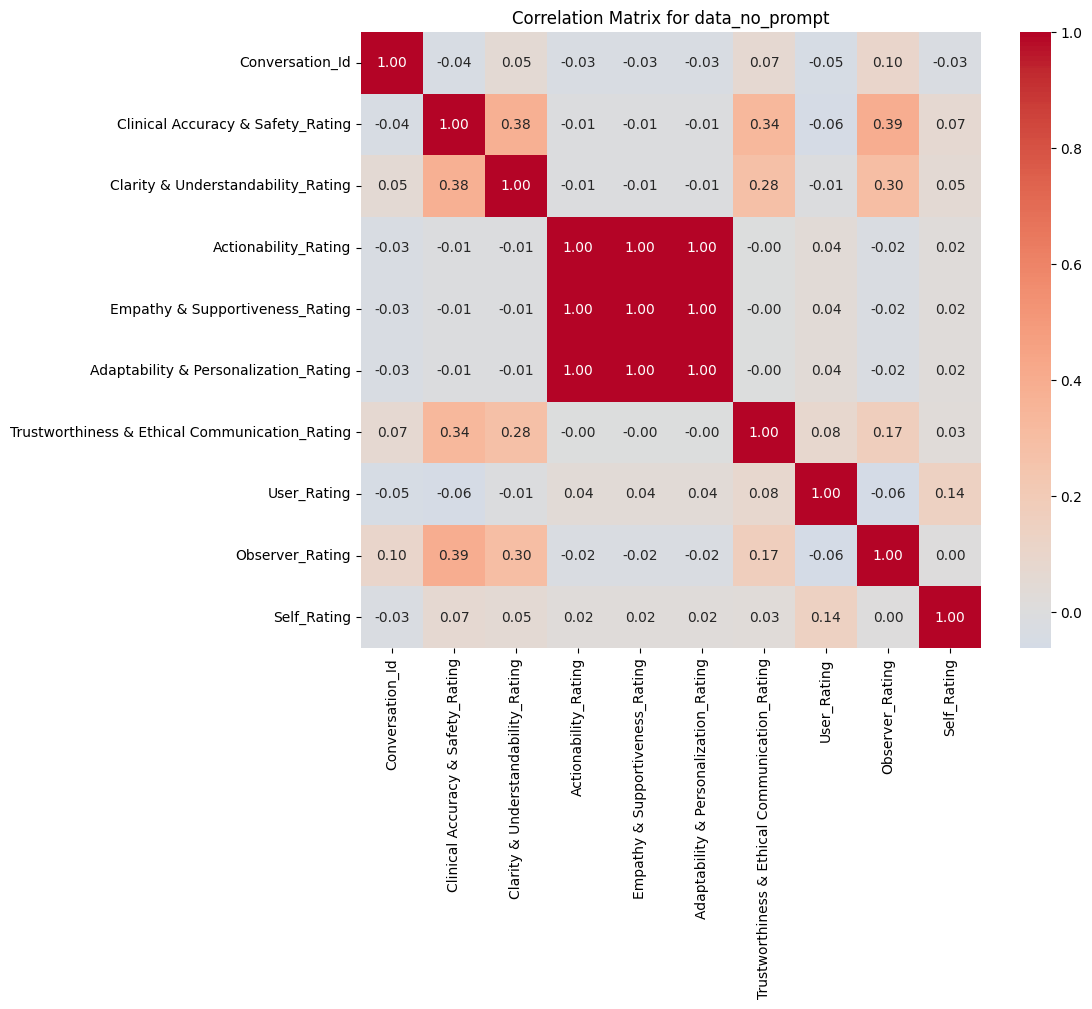

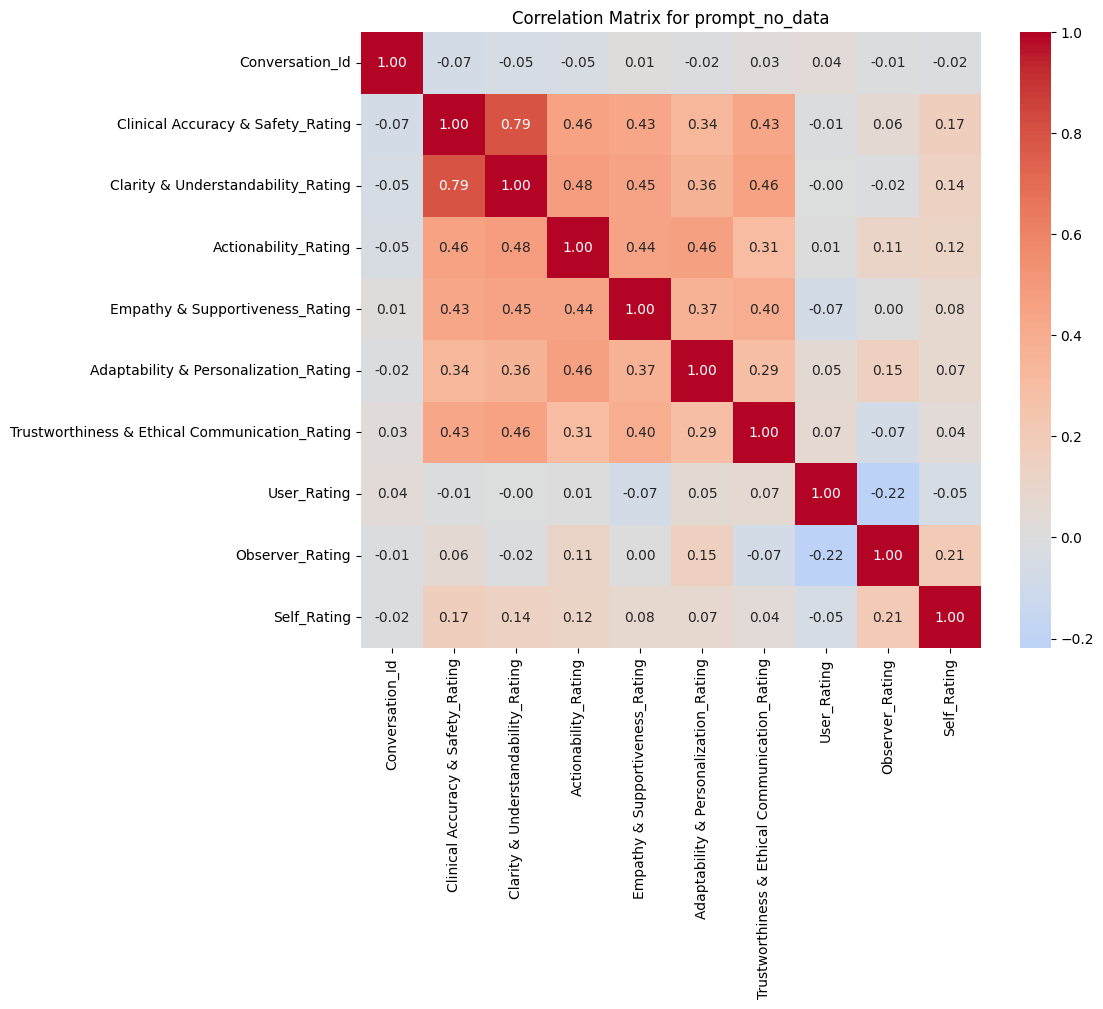

In [6]:
# Correlation analysis within each baseline type
for baseline in ['data_no_prompt', 'prompt_no_data']:
    subset = df[df['baseline_type'] == baseline]
    numeric_cols = subset.select_dtypes(include=[np.number]).columns
    corr = subset[numeric_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title(f'Correlation Matrix for {baseline}')
    plt.show()

In [7]:
# Statistical tests: compare means between baseline types for each criterion
results = []
for col in criteria_cols + ['User_Rating', 'Observer_Rating', 'Self_Rating']:
    group1 = df[df['baseline_type'] == 'data_no_prompt'][col].dropna()
    group2 = df[df['baseline_type'] == 'prompt_no_data'][col].dropna()
    if len(group1) > 1 and len(group2) > 1:
        t_stat, p_val = ttest_ind(group1, group2)
        results.append({
            'criterion': col,
            'mean_data_no_prompt': group1.mean(),
            'mean_prompt_no_data': group2.mean(),
            't_stat': t_stat,
            'p_value': p_val,
            'significant': p_val < 0.05
        })
results_df = pd.DataFrame(results)
display(results_df)

,criterion,mean_data_no_prompt,mean_prompt_no_data,t_stat,p_value,significant
0,Clinical Accuracy & Safety_Rating,7.850000,7.270370,7.226764,1.488990e-12,True
1,Clarity & Understandability_Rating,7.947059,7.333333,8.535524,1.115326e-16,True
2,Actionability_Rating,7.994118,7.759259,5.218307,2.480864e-07,True
3,Empathy & Supportiveness_Rating,7.994118,7.803704,4.573793,5.806702e-06,True
4,Adaptability & Personalization_Rating,7.994118,7.866667,3.723727,2.145527e-04,True
5,Trustworthiness & Ethical Communication_Rating,7.982353,7.622222,5.668172,2.230877e-08,True
6,User_Rating,9.044118,8.722222,2.620620,8.996390e-03,True
7,Observer_Rating,7.520588,7.574074,-0.524118,6.003874e-01,False
8,Self_Rating,5.414706,7.203704,-18.848178,9.434177e-63,True
9,User_Rating,9.044118,8.722222,2.620620,8.996390e-03,True
